# Analyse de la Construction XOR NRBG (Hybrid Generator)

Ce notebook analyse une construction **XOR NRBG**. L'idée est de combiner deux générateurs :
1. **Source A (LCG)** : Simple et cyclique.
2. **Source B (MT19937)** : Plus complexe.


In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chisquare, kstest

sys.path.append(os.path.abspath('../generators'))
from lcg import LCG
from mt19937 import mt19937
from xor_nrbg import XOR_NRBG

N = 50000
seed_a, seed_b = 42, 123

source_lcg = LCG(seed=seed_a)
source_mt = mt19937(seed=seed_b)
nrbg = XOR_NRBG(source_lcg, source_mt)

data_xor = [nrbg.next_byte() for _ in range(N)]

print(f"Génération de {N} octets hybrides terminée.")

Génération de 50000 octets hybrides terminée.


## 1. Analyse de l'Uniformité et du Désordre (Entropie)



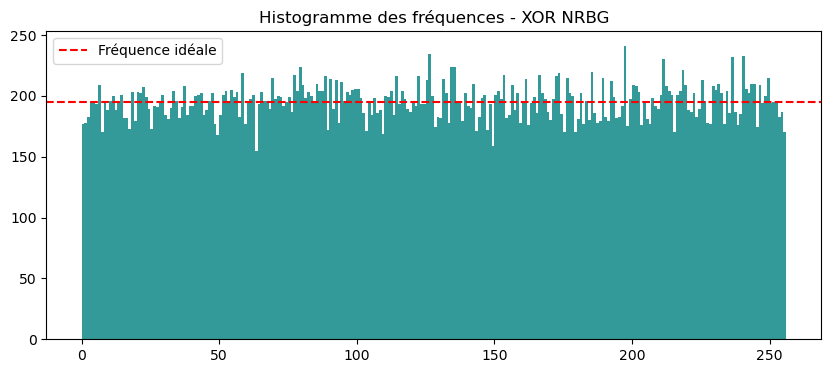

Entropie de Shannon : 7.996291 bits/octet


In [2]:
# Histogramme
plt.figure(figsize=(10, 4))
plt.hist(data_xor, bins=256, range=(0, 256), color='teal', alpha=0.8)
plt.axhline(y=N/256, color='red', linestyle='--', label="Fréquence idéale")
plt.title("Histogramme des fréquences - XOR NRBG")
plt.legend()
plt.show()

# Entropie
def shannon_entropy(data):
    _, counts = np.unique(data, return_counts=True)
    probs = counts / len(data)
    return -np.sum(probs * np.log2(probs))

print(f"Entropie de Shannon : {shannon_entropy(data_xor):.6f} bits/octet")

## 2. Tests de Distribution (Chi-Carré & KS)


In [3]:
# Test Chi2
obs, _ = np.histogram(data_xor, bins=256, range=(0, 256))
chi2_stat, chi2_p = chisquare(obs)

# Test KS
data_norm = np.array(data_xor) / 255.0
ks_stat, ks_p = kstest(data_norm, 'uniform')

print(f"P-value Chi-Carré : {chi2_p:.5f}")
print(f"P-value Kolmogorov-Smirnov : {ks_p:.5f}")

P-value Chi-Carré : 0.44581
P-value Kolmogorov-Smirnov : 0.07477


## 3. Analyse de l'Autocorrélation (Indépendance)



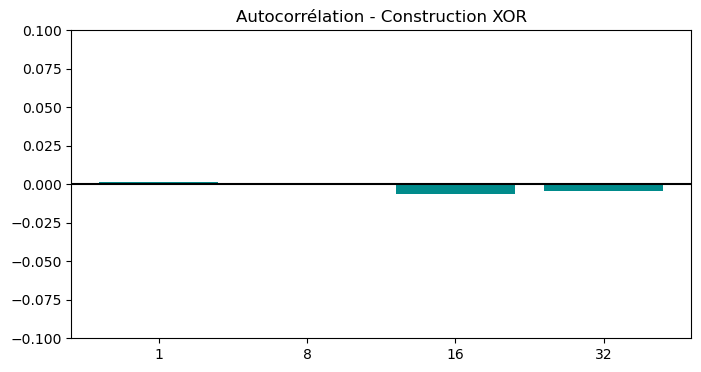

Lag 1: 0.001654
Lag 8: -0.000637
Lag 16: -0.006282
Lag 32: -0.004092


In [4]:
def plot_autocorr(data, lags=[1, 8, 16, 32]):
    corrs = [np.corrcoef(data[:-lag], data[lag:])[0, 1] for lag in lags]
    plt.figure(figsize=(8, 4))
    plt.bar([str(l) for l in lags], corrs, color='darkcyan')
    plt.axhline(y=0, color='black')
    plt.ylim(-0.1, 0.1)
    plt.title("Autocorrélation - Construction XOR")
    plt.show()
    for l, c in zip(lags, corrs):
        print(f"Lag {l}: {c:.6f}")

plot_autocorr(data_xor)